In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Gaming_Hours_vs_Performance_1000_Rows.csv')

In [3]:
df.head()

,User_ID,Age,Gender,Occupation,Game_Type,Daily_Gaming_Hours,Weekly_Gaming_Hours,Primary_Gaming_Time,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level,Performance_Impact
0,U0001,21,Male,Working Professional,Action,4.0,28.0,Morning,4.6,6,4,69,66,Negative
1,U0002,35,Female,Student,Sports,1.0,7.0,Night,5.4,2,7,67,72,Neutral
2,U0003,26,Male,Student,Puzzle,2.0,14.0,Morning,8.0,4,8,82,82,Positive
3,U0004,32,Male,Working Professional,Action,1.0,7.0,Night,4.9,7,7,71,66,Neutral
4,U0005,19,Male,Working Professional,Action,2.1,14.7,Morning,7.0,7,7,67,63,Neutral


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User_ID                 1000 non-null   object 
 1   Age                     1000 non-null   int64  
 2   Gender                  1000 non-null   object 
 3   Occupation              1000 non-null   object 
 4   Game_Type               1000 non-null   object 
 5   Daily_Gaming_Hours      1000 non-null   float64
 6   Weekly_Gaming_Hours     1000 non-null   float64
 7   Primary_Gaming_Time     1000 non-null   object 
 8   Sleep_Hours             1000 non-null   float64
 9   Stress_Level            1000 non-null   int64  
 10  Focus_Level             1000 non-null   int64  
 11  Academic_or_Work_Score  1000 non-null   int64  
 12  Productivity_Level      1000 non-null   int64  
 13  Performance_Impact      1000 non-null   object 
dtypes: float64(3), int64(5), object(6)
memory

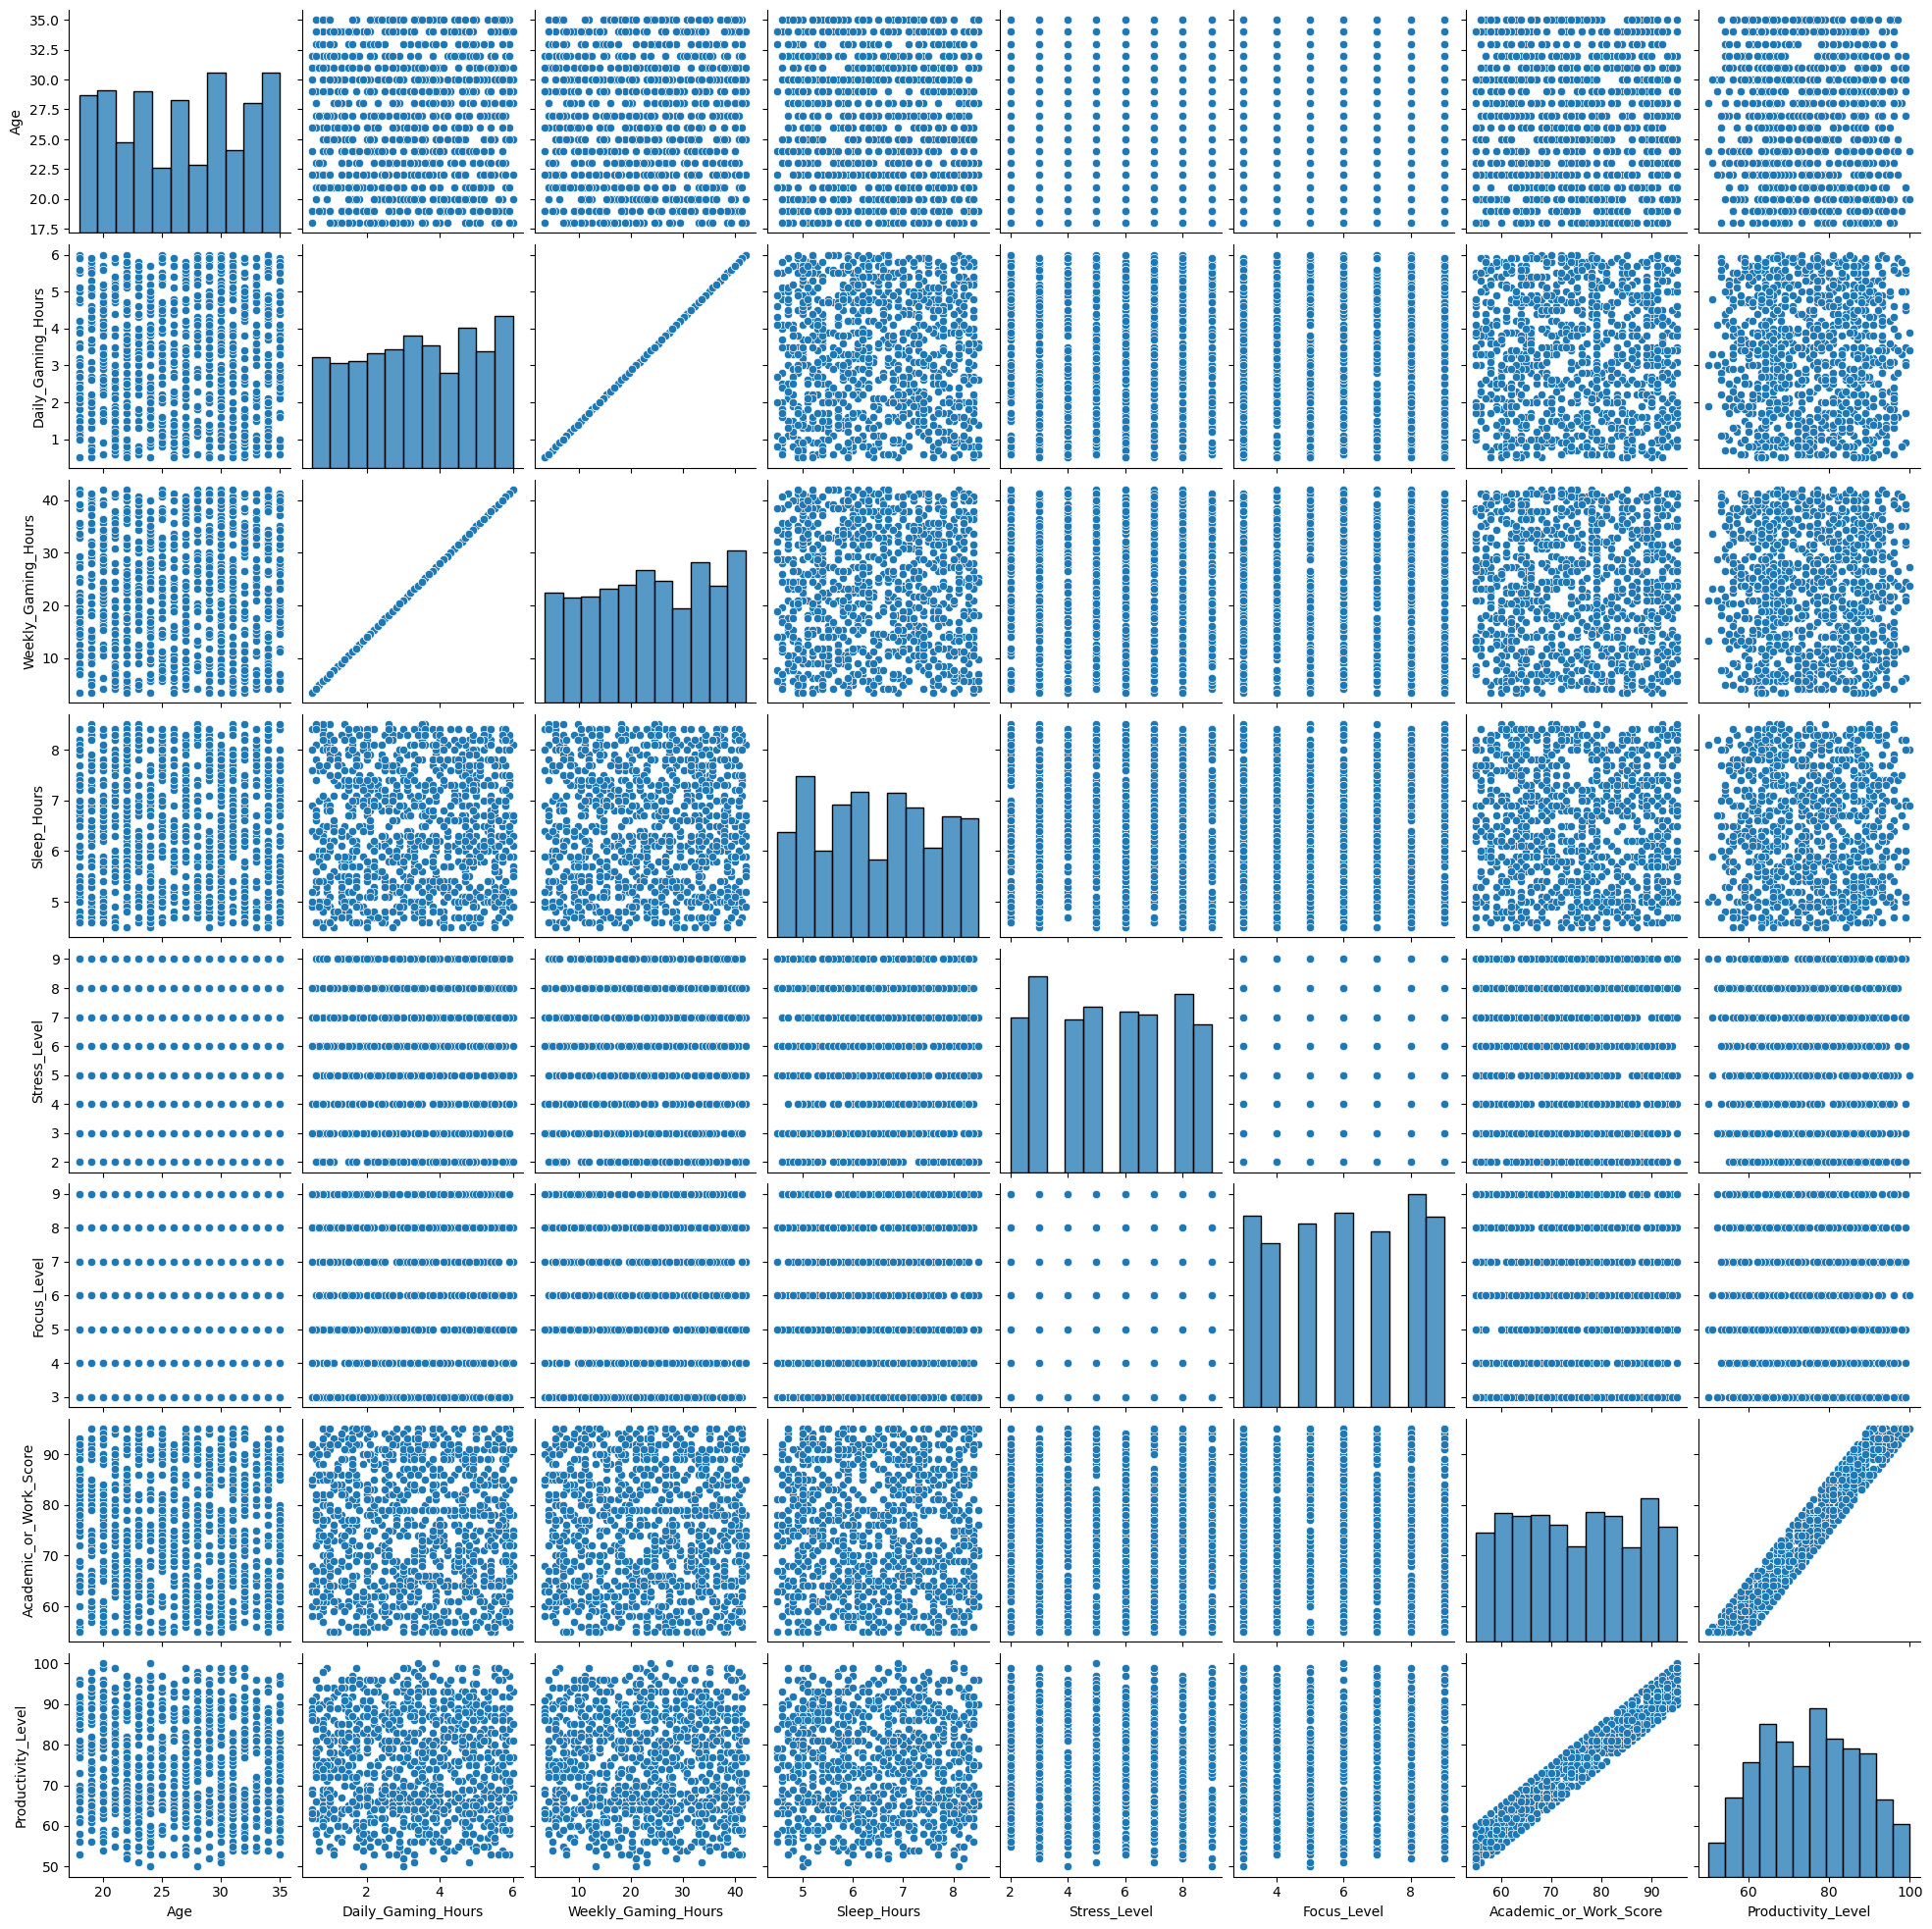

In [9]:
sns.pairplot(df)

In [10]:
cat_cols=[x for x in df.columns if df[x].dtype=='O']

In [13]:
cat_cols.remove('User_ID')

In [14]:
for col in cat_cols:
    print(df[col].value_counts())

Gender
Female    513
Male      487
Name: count, dtype: int64
Occupation
Student                 524
Working Professional    476
Name: count, dtype: int64
Game_Type
Simulation    192
Action        180
Sports        161
Casual        160
Strategy      157
Puzzle        150
Name: count, dtype: int64
Primary_Gaming_Time
Morning    341
Evening    338
Night      321
Name: count, dtype: int64
Performance_Impact
Neutral     762
Negative    135
Positive    103
Name: count, dtype: int64


In [36]:
ct = pd.crosstab(df["Game_Type"], df["Primary_Gaming_Time"])
print(ct)

Primary_Gaming_Time  Evening  Morning  Night
Game_Type                                   
Action                    60       67     53
Casual                    60       41     59
Puzzle                    60       50     40
Simulation                60       71     61
Sports                    55       50     56
Strategy                  43       62     52


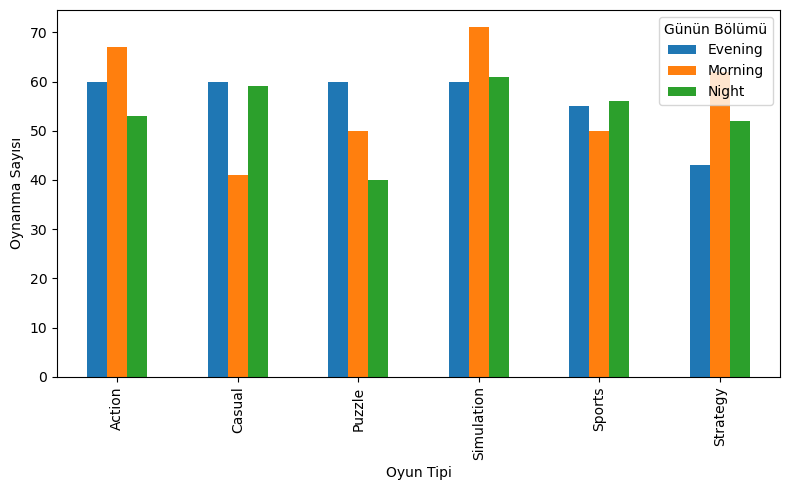

In [37]:
ct.plot(
    kind="bar",
    figsize=(8,5)
)


plt.xlabel("Oyun Tipi")
plt.ylabel("Oynanma Sayısı")
plt.legend(title="Günün Bölümü")
plt.tight_layout()
plt.show()

In [38]:
ct = pd.crosstab(df["Game_Type"], df["Performance_Impact"])
print(ct)

Performance_Impact  Negative  Neutral  Positive
Game_Type                                      
Action                    29      134        17
Casual                    24      124        12
Puzzle                    23      111        16
Simulation                26      146        20
Sports                    21      122        18
Strategy                  12      125        20


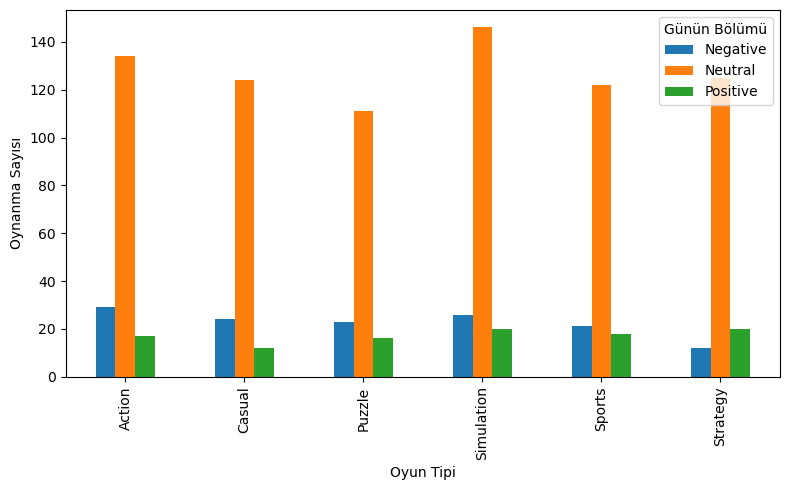

In [39]:
ct.plot(
    kind="bar",
    figsize=(8,5)
)


plt.xlabel("Oyun Tipi")
plt.ylabel("Oynanma Sayısı")
plt.legend(title="Günün Bölümü")
plt.tight_layout()
plt.show()

In [40]:
# STRATEJİ OYUNLARI DİĞERLERİNE NAZARAN BİRAZ DAHA POZİTİF ANCAK GENELİ NEGATİF ETKİYE SAHİP 

In [41]:
ct = pd.crosstab(df["Gender"], df["Game_Type"])
print(ct)

Game_Type  Action  Casual  Puzzle  Simulation  Sports  Strategy
Gender                                                         
Female         80      95      85          99      76        78
Male          100      65      65          93      85        79


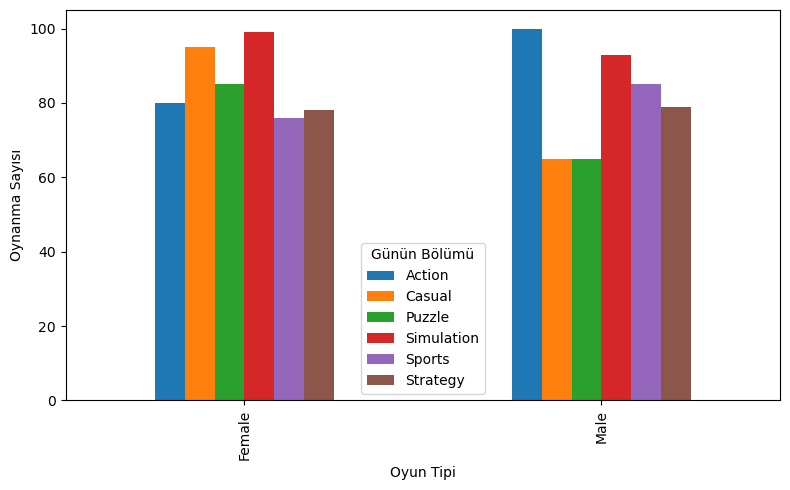

In [42]:
ct.plot(
    kind="bar",
    figsize=(8,5)
)


plt.xlabel("Oyun Tipi")
plt.ylabel("Oynanma Sayısı")
plt.legend(title="Günün Bölümü")
plt.tight_layout()
plt.show()

In [43]:
#KADINLAR BELİRGİN OLARAK CASUAL VE PUZZLE DA DAHA FAZLA OYNAMAYA SAHİP ERKEKLER İSE ACTİON KISMINDA ÖNE GEÇMİŞ

In [44]:
cat_cols.remove('Performance_Impact')

In [45]:
cat_cols

['Gender', 'Occupation', 'Game_Type', 'Primary_Gaming_Time']

In [46]:
df=pd.get_dummies(data=df,columns=cat_cols,drop_first=True,dtype=int)

In [47]:
df.head()

,User_ID,Age,Daily_Gaming_Hours,Weekly_Gaming_Hours,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level,Performance_Impact,Gender_Male,Occupation_Working Professional,Game_Type_Casual,Game_Type_Puzzle,Game_Type_Simulation,Game_Type_Sports,Game_Type_Strategy,Primary_Gaming_Time_Morning,Primary_Gaming_Time_Night
0,U0001,21,4.0,28.0,4.6,6,4,69,66,Negative,1,1,0,0,0,0,0,1,0
1,U0002,35,1.0,7.0,5.4,2,7,67,72,Neutral,0,0,0,0,0,1,0,0,1
2,U0003,26,2.0,14.0,8.0,4,8,82,82,Positive,1,0,0,1,0,0,0,1,0
3,U0004,32,1.0,7.0,4.9,7,7,71,66,Neutral,1,1,0,0,0,0,0,0,1
4,U0005,19,2.1,14.7,7.0,7,7,67,63,Neutral,1,1,0,0,0,0,0,1,0


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [49]:
X=df.drop(['User_ID','Performance_Impact'],axis=1)
y=df['Performance_Impact']

In [50]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=11)

In [52]:
scaler=StandardScaler()

In [53]:
X_train_scaled=scaler.fit_transform(X_train)

In [54]:
X_test_scaled=scaler.transform(X_test)

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [60]:
decision_tree=DecisionTreeClassifier()

In [61]:
parameters={
    'criterion':['gini','entropy','log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,3,5,7,9,11,13],
    'max_features':['sqrt','log2']
    
}

In [62]:
grid_search=GridSearchCV(estimator=decision_tree,param_grid=parameters,cv=3)

In [63]:
grid_search.fit(X_train_scaled,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 3, ...], 'max_features': ['sqrt', 'log2'], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'log_loss'


In [64]:
grid_search.best_score_

1.0

In [65]:
y_pred=grid_search.predict(X_test_scaled)

In [66]:
from sklearn.metrics import classification_report,confusion_matrix

In [68]:
class_names=['Neutral','Negative','Positive']

In [69]:
cm=confusion_matrix(y_pred,y_test)

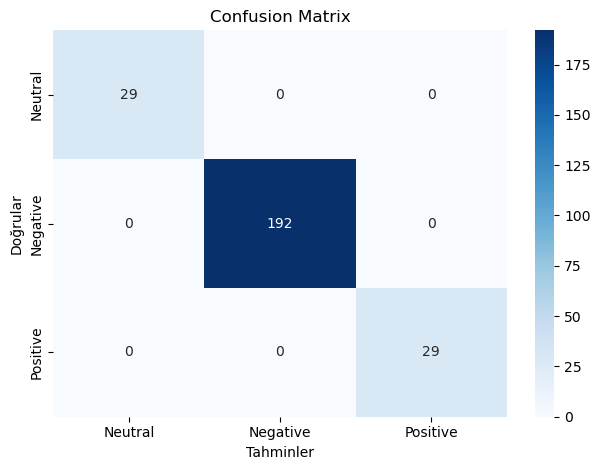

In [72]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names

)

plt.xlabel('Tahminler')
plt.ylabel('Doğrular')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [73]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        29
     Neutral       1.00      1.00      1.00       192
    Positive       1.00      1.00      1.00        29

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

